# <center> **Домашнее задание №2** </center>

*Фамилия Имя: Жарков Дмитрий*

## **Задача 1. Генератор** **(15 баллов)**

#### **Задание**

Напишите **генератор**, который принимает коллекцию с вложенными итерируемыми объектами, а возвращает каждый элемент последовательно.

**Примеры работы генератора**


```python
[[1, 2, 3], [4, [5, 6, [7, 8]]]] → [1, 2, 3, 4, 5, 6, 7, 8]
```

```python
[1, 2, 'abc', [2, 4], {'key': 'value'}] → [1, 2, 'a', 'b', 'c', 2, 4, 'k', 'e', 'y']
```

*Обратите внимание: итерация по словарям происходит **по ключам**.*


**Подсказка**

Для проверки, что объект является итерируемым, используйте:

```python
from collections.abc import Iterable

# В вашем коде:
assert isinstance(x, Iterable), 'Объект не итерируемый'
```

Функция `isinstance(x, tp)` проверяет, относится ли объект `x` к типу `tp`.

*Не забудьте обработать строки особым образом, так как они тоже являются итерируемыми объектами!*

In [ ]:
from collections.abc import Iterable

print(isinstance(1, Iterable))
print(isinstance('abc', Iterable))

False
True


In [3]:
from collections.abc import Iterable


def get_consistent_object(x: list):
    for i in x:
        if isinstance(i, dict):
            yield from get_consistent_object(i.keys())
        elif isinstance(i, Iterable) and not isinstance(i, (str, bytes, dict)):
            yield from get_consistent_object(i)
        elif isinstance(i, str):
            yield from i
        else:
            yield i

print(list(get_consistent_object([1, 2, 'abc', [2, 4], {'key': 'value'}])))
print(list(get_consistent_object([[1, 2, 3], [4, [5, 6, [7, 8]]]])))

[1, 2, 'a', 'b', 'c', 2, 4, 'k', 'e', 'y']
[1, 2, 3, 4, 5, 6, 7, 8]


## **Задача 2. itertools** **(15 баллов)**

#### **О модуле itertools**

Модуль `itertools` представляет множество инструментов для работы с итераторами.

Официальная документация: https://docs.python.org/3/library/itertools.html

#### **Задание**

**Входные данные:**
1. Числа вводятся **через пробел** в одной строке
2. Затем вводится число **`n`**

**Задача:** Напишите программу, которая находит все **уникальные пары чисел** из списка, где сумма каждой пары равна числу `n`.

*Можете использовать модуль `itertools` для решения!*

#### **Пример работы**

**Вход:**
```
1 2 3 4 5 6
7
```

**Выход:**
```python
[(1, 6), (2, 5), (3, 4)]
```

*Программа выводит пары чисел, которые в сумме дают 7.*

**Важные условия**

- Гарантируется, что числа во входной последовательности не повторяются
- Пары в кортежах должны быть в том же порядке, что и в исходном списке
  - Например: `(1, 6)` — правильно, `(6, 1)` — неправильно (если 1 идёт раньше 6 в списке)
- Пара числа с самим собой не подходят 

In [4]:
import itertools


number_list = list(map(int, input().split()))
n = int(input())

result = []

for i in itertools.combinations(number_list, 2):
    if sum(i) == n:
        result.append(i)

result

1 2 3 4 5 6
7


[(1, 6), (2, 5), (3, 4)]

**Задание 2.1 (2.5 балла)**

Вводятся числа в одной строке через пробел.

Например, '4 2 5 2 5 1'

Необходимо найти наименьшее нечетное число. Например, для примера выше это 1.

Решение должно занимать ровно одну строку любой длины.

Запрещено использовать циклы, условные операторы и list comprehension.


In [22]:
min(filter(lambda x: x % 2 != 0, list(map(int, input().split()))), default=None)

4 2 5 2 5 1


1

**Задание 2.2 (2.5 балла)**

Вводится одно число n.

Используя модуль `itertools`, выведите в одной строке через запятую и пробел факториалы чисел от 0 до n.

Запрещено использовать циклы, условные операторы и list comprehension.

Например, для n = 7 на экран надо вывести:

1, 1, 2, 6, 24, 120, 720, 5040

In [25]:
import itertools
import operator


n = int(input())
result = list(itertools.accumulate(itertools.chain([1], range(1, 1 + n)), operator.mul))
result

7


[1, 1, 2, 6, 24, 120, 720, 5040]

### **Задача 3. Numpy (22 балла)**

#### 3.1 **Вспоминаем, что такое numpy**

Создайте с помощью `np.random.randint` numpy массив из 20-ти рандомных чисел. **(0.5 балла)**

Посчитайте с помощью методов `numpy` и выведите на экран:

- среднее значение в массиве **(0.5 балла)**
- минимальное значение в массиве **(0.5 балла)**
- максимальное значение в массиве **(0.5 балла)**
- индекс минимального элемента в массиве **(0.5 балла)**

In [26]:
import numpy as np
import time # понадобится для замера времени в следующих пунктах

In [39]:
random_numbers = np.random.randint(0, 100, 20)
print(random_numbers)
print(random_numbers.mean())
print(random_numbers.min())
print(random_numbers.max())
print(random_numbers.argmin())

[79 25 75 16 19 32 83 89 17 65 79 68 95 16 10 41  8 27 43 70]
47.85
8
95
16


Создайте два numpy массива: в первом должны быть четные числа от 2 до 14 включительно, а во втором — числа 7, 11, 17, 18, 23, 30, 45.

- Сложите массивы и возведите элементы получившегося массива в квадрат
- Выведите все элементы из первого массива, которые стоят на тех местах, где элементы второго массива больше 12 и дают остаток 3 при делении на 5.
- Для первого массива найдите остатки от деления на 2, а для второго — на 3.

**Общий балл: 1.5 балла**

In [40]:
A = np.arange(2, 15, 2)
B = np.array([7, 11, 17, 18, 23, 30, 45])

squarred_array = (A + B) ** 2
print(squarred_array)

indices = np.where((B > 12) & (B % 5 == 3))
print(A[indices])

print(A % 2)
print(A % 3)

[  81  225  529  676 1089 1764 3481]
[ 8 10]
[0 0 0 0 0 0 0]
[2 1 0 2 1 0 2]


1. Сгенерируйте рандомный массив b размера 3x1.
2. Сгенерируйте матрицу С размера 3x3.
3. Решите систему Cx = b с помощью `numpy.linalg.solve`
4. Подумайте/погуглите, в каком случае `numpy.linalg.solve` вернет ошибку LinAlgError. Воспроизведите этот случай.

**Общий балл: 2 балла**

In [41]:
b = np.random.randint(0, 100, (3, 1))
print(b)
c = np.random.randint(0, 100, (3, 3))
print(c)
x = np.linalg.solve(c, b)
print(x)

[[30]
 [81]
 [59]]
[[92 21 15]
 [97 46 40]
 [10  9 29]]
[[-0.00717926]
 [ 0.00649236]
 [ 2.0349435 ]]


In [42]:
error_case = np.linalg.solve(np.zeros(2), b)
print(error_case)

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/alex_mcqueen2/Jupiter/my_project_env/lib/python3.9/site-packages/IPython/core/interactiveshell.py", line 3460, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_3285/491048739.py", line 1, in <module>
    error_case = np.linalg.solve(np.zeros(2), b)
  File "<__array_function__ internals>", line 200, in solve
  File "/home/alex_mcqueen2/Jupiter/my_project_env/lib/python3.9/site-packages/numpy/linalg/linalg.py", line 372, in solve
    _assert_stacked_2d(a)
  File "/home/alex_mcqueen2/Jupiter/my_project_env/lib/python3.9/site-packages/numpy/linalg/linalg.py", line 183, in _assert_stacked_2d
    raise LinAlgError('%d-dimensional array given. Array must be '
numpy.linalg.LinAlgError: 1-dimensional array given. Array must be at least two-dimensional

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/home/alex_mcqueen2/Jupiter/my_project_env/li

#### **3.2 Сравнение производительности**

Сравните производительность операций умножения матриц с использованием библиотеки NumPy и стандартных списков Python для матриц размером от 2x2 до 100x100.

1. Сгенерируйте две матрицы A и B случайного размера nxn, заполненные случайными целыми числами от 1 до 50. **(1 балл)**
2. Используя библиотеку NumPy, выполните умножение матриц A и B. Измерьте время выполнения операции. **(2 балла)**
3. Реализуйте функцию для умножения матриц с помощью стандартных списков Python. Измерьте время выполнения этой операции. **(3 балла)**
4. Сделайте вышеперечисленные пункты для n=2,...100. **(4 балла)**
5. Для какого-нибудь n проверьте, совпадают ли результаты. **(1 балл)**
7. Для каждого n выведите на экран размеры матриц и время выполнения умножения для обеих реализаций. **(2.5 баллов)**
8. Постройте график, где по оси X будет размер матрицы, по оси Y - время выполнения операции. Постройте два графика (для numpy и для стандартных списков) **(2.5 баллов)**

n=2: NumPy: 0.000018 сек, Python: 0.000013 сек
n=3: NumPy: 0.000009 сек, Python: 0.000021 сек
n=4: NumPy: 0.000009 сек, Python: 0.000034 сек
n=5: NumPy: 0.000008 сек, Python: 0.000057 сек
n=6: NumPy: 0.000009 сек, Python: 0.000086 сек
n=7: NumPy: 0.000009 сек, Python: 0.000130 сек
n=8: NumPy: 0.000009 сек, Python: 0.000186 сек
n=9: NumPy: 0.000009 сек, Python: 0.000263 сек
n=10: NumPy: 0.000009 сек, Python: 0.000334 сек
n=11: NumPy: 0.000010 сек, Python: 0.000449 сек
n=12: NumPy: 0.000010 сек, Python: 0.000564 сек
n=13: NumPy: 0.000011 сек, Python: 0.000713 сек
n=14: NumPy: 0.000012 сек, Python: 0.000877 сек
n=15: NumPy: 0.000013 сек, Python: 0.001066 сек
n=16: NumPy: 0.000014 сек, Python: 0.001303 сек
n=17: NumPy: 0.000015 сек, Python: 0.001543 сек
n=18: NumPy: 0.000056 сек, Python: 0.001818 сек
n=19: NumPy: 0.000019 сек, Python: 0.002131 сек
n=20: NumPy: 0.000026 сек, Python: 0.002450 сек
n=21: NumPy: 0.000021 сек, Python: 0.002872 сек
n=22: NumPy: 0.000024 сек, Python: 0.003237 сек


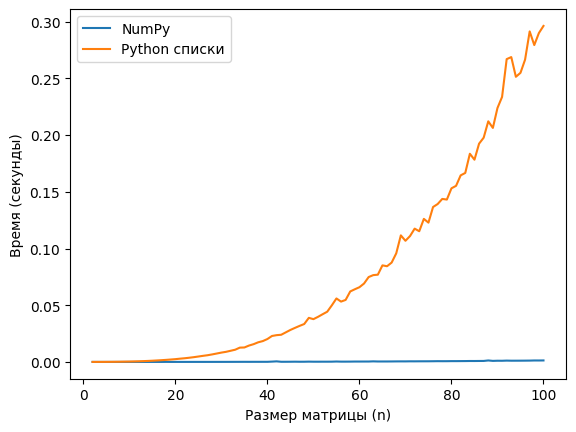

In [43]:
import matplotlib.pyplot as plt

def multiply_matrices(A, B):
    n = len(A)
    result = [[0 for _ in range(n)] for _ in range(n)]

    for i in range(n):
        for j in range(n):
            for k in range(n):
                result[i][j] += A[i][k] * B[k][j]
    return result

sizes = []
numpy_times = []
python_times = []

for n in range(2, 101):
    A = np.random.randint(1, 50, (n, n))
    B = np.random.randint(1, 50, (n, n))

    start_time = time.time()
    result_numpy = A @ B
    numpy_time = time.time() - start_time

    A_list = A.tolist()
    B_list = B.tolist()

    start_time = time.time()
    result_python = multiply_matrices(A_list, B_list)
    python_time = time.time() - start_time

    sizes.append(n)
    numpy_times.append(numpy_time)
    python_times.append(python_time)

    print(f"n={n}: NumPy: {numpy_time:.6f} сек, Python: {python_time:.6f} сек")

print("\nПроверка для n=5:")
A_check = np.random.randint(1, 50, (5, 5))
B_check = np.random.randint(1, 50, (5, 5))

result_numpy = A_check @ B_check
result_python = multiply_matrices(A_check.tolist(), B_check.tolist())

print("Результаты совпадают:", np.allclose(result_numpy, result_python))

plt.plot(sizes, numpy_times, label='NumPy')
plt.plot(sizes, python_times, label='Python списки')
plt.xlabel('Размер матрицы (n)')
plt.ylabel('Время (секунды)')
plt.legend()
plt.show()

### **Задача 4. Введение в pandas (8 баллов)**

Работаем с датасетом по кредитному скорингу `loan_data.csv`. Скачайте его здесь https://disk.yandex.ru/d/xkujsz3HFJ8taw и считайте с помощью `pd.read_csv`.

#### **Используемые столбцы:**

- `credit.policy` - 1, если клиент соответствует критериям выдачи кредита, 0 в противном случае.
- `purpose` - цель кредита (принимает значения "credit_card", "debt_consolidation", "educational", "home_improvement", "major_purchase", "small_business" и "all_other").
- `int.rate` - процентная ставка по кредиту.
- `installment` - ежемесячный платеж, причитающийся заемщику в случае финансирования кредита.
- `log.annual.inc` - натуральный логарифм годового дохода заемщика, представленного им самим.
- `dti` - отношение долга к доходу заемщика (сумма долга, деленная на годовой доход).
- `fico` - кредитный рейтинг FICO заемщика.
- `days.with.cr.line` - количество дней, в течение которых у заемщика была открыта кредитная линия.
- `revol.bal` - возобновляемый баланс заемщика (сумма, не выплаченная в конце платежного цикла по кредитной карте).
- `revol.util` - коэффициент использования возобновляемой кредитной линии заемщиком (сумма использованной кредитной линии по отношению к общему объему доступных кредитов).
- `inq.last.6mths` - количество запросов заемщика от кредиторов за последние 6 месяцев.
- `delinq.2yrs` - количество раз, когда заемщик просрочивал платеж более чем на 30 дней за последние 2 года.
- `pub.rec` - количество негативных публичных записей о заемщике (заявления о банкротстве, налоговые залоги или судебные решения).
- `not.fully.paid` - неполностью выплаченный кредит ранее.

#### **Задания**

**Каждый пункт весит 0.6 балла, но не более 8 баллов за задание.**

1. Выведите первые 5 строк датасета.
2. Сколько в датасете строк и столбцов?
3. Есть ли в датасете пропуски? В каких столбцах сколько пропусков, если есть?
4. Выведите все описательные статистики по числовым столбцам единым методом.
5. Какая средняя процентная ставка по кредиту?
6. Сколько клиентов соответствует условиям выдачи кредита?
7. Как отличается средний логарифм годового дохода заемщиков, которые соответствуют условиям выдачи кредита и тех, кто не соответствует?
8. Какой медианный ежемесячный платеж?
9. Сколько уникальных значений у переменной `not.fully.paid`?
10. Сделайте столбец `annual.inc` для подсчета годового дохода (выполните обратное преобразование столбца `log.annual.inc`)
11. Сделайте группировку по двум переменным: `credit.policy` и `not.fully.paid`. Посчитайте для каждой группы количество клиентов, средний ежемесячный платеж, медианный ежемесячный платеж, средний годовой доход.
12. Выведите топ-10 клиентов по уровню дохода среди тех, кто не удовлетворяет критериям выдачи кредита.
13. Есть ли выбросы у переменной `annual.inc`? Выбросами считайте наблюдения, которые не лежат в границах `[Q1−1.5IQR,Q3+1.5IQR]`, где IQR - межквартильный размах, Q1 - 25 перцентиль, Q3 - 75 перцентиль.
14. Постройте распределения переменных `annual.inc` и `log.annual.inc`

Первые 5 строк: 
   credit.policy             purpose  int.rate  installment  log.annual.inc  \
0              1  debt_consolidation    0.1189       829.10       11.350407   
1              1         credit_card    0.1071       228.22       11.082143   
2              1  debt_consolidation    0.1357       366.86       10.373491   
3              1  debt_consolidation    0.1008       162.34       11.350407   
4              1         credit_card    0.1426       102.92       11.299732   

     dti  fico  days.with.cr.line  revol.bal  revol.util  inq.last.6mths  \
0  19.48   737        5639.958333      28854        52.1               0   
1  14.29   707        2760.000000      33623        76.7               0   
2  11.63   682        4710.000000       3511        25.6               1   
3   8.10   712        2699.958333      33667        73.2               1   
4  14.97   667        4066.000000       4740        39.5               0   

   delinq.2yrs  pub.rec  not.fully.paid  
0        

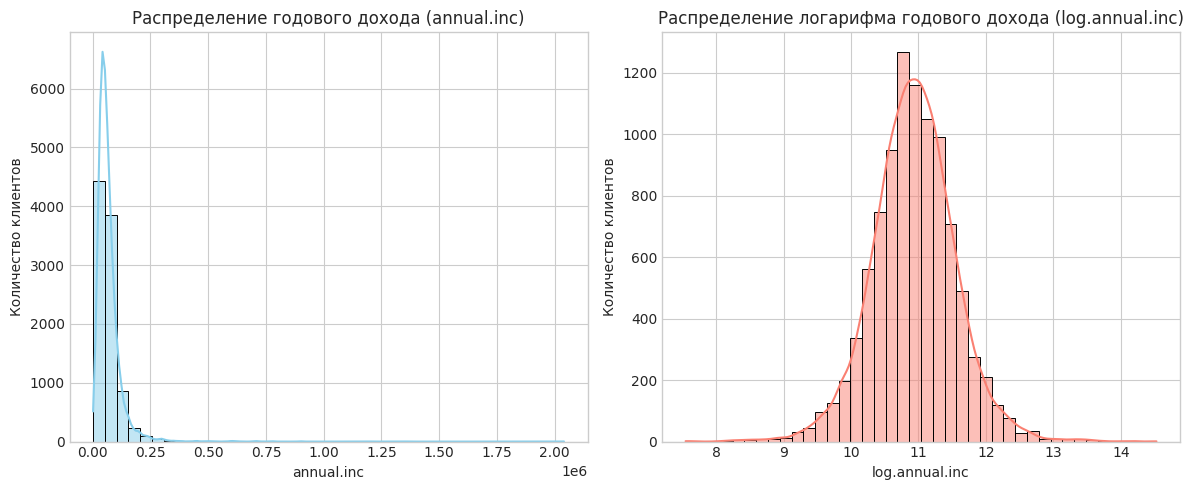

In [5]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


data = pd.read_csv('loan_data.csv')

print("Первые 5 строк: ")
print(data.head())

print(f"\nКолечество строк 9578 и столбцов 14\n")
print(data.info())

print(f"\nПропущенные значения\n")
print(data.isna())

print(f"\nОписательная статистика по числовым столбцам")
print(data.describe())

print(f"\nСредняя процентная ставка по кредиту")
print(data["int.rate"].mean())

print(f"\nКоличество клиентов, соответствующие условиям кредита")
print(data["credit.policy"].count())

print(f"\nРазличие среднего логарифма дохода заемщиков, соотвествующих/несоотвествующих условиям выдачи кредитов")
mean_credit_ok = data[data["credit.policy"] == 1]["log.annual.inc"].mean()
mean_credit_not_ok = data[data["credit.policy"] == 0]["log.annual.inc"].mean()
print(mean_credit_ok)
print(mean_credit_not_ok)
print(f"\nРазница: {mean_credit_ok - mean_credit_not_ok}")

print(f"\nМедианный ежемесячный платеж")
print(data["installment"].median())

print(f"\nКоличество уникальных значений `not.fully.paid`")
print(data["not.fully.paid"].unique().__len__())

data["annual.inc"] = np.exp(data["log.annual.inc"])
print("\nПервые 5 строк после добавления annual.inc:")
print(data[["log.annual.inc", "annual.inc"]].head())

print(f"\nГруппировка по `credit.policty` и `not.fully.paid`")
print(data.groupby(by=["credit.policy", "not.fully.paid"]).agg(
    clients_count=("credit.policy", "count"),
    mean_installment=("installment", "mean"),
    median_installment=("installment", "median"),
    mean_annual_inc=("annual.inc", "mean")
))

print(f"\nТоп-10 клиентов по уровню дохода, которые не удовлетворяют условиям выдачи кредита")
print(data[data["credit.policy"] == 0].sort_values(by="annual.inc", ascending=False).head(10))

print(f"\nВыбросы переменной `annual.inc`")
Q1 = data["annual.inc"].quantile(0.25)
Q3 = data["annual.inc"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = data[(data["annual.inc"] < lower_bound) | (data["annual.inc"] > upper_bound)]

print(f"Q1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"Нижняя граница = {lower_bound:.2f}")
print(f"Верхняя граница = {upper_bound:.2f}")
print(f"Количество выбросов: {len(outliers)}")

print(f"\nРаспределения переменных `annual.inc` и `log.annual.inc`")
plt.style.use("seaborn-v0_8-whitegrid")
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data["annual.inc"], bins=40, kde=True, color="skyblue")
plt.title("Распределение годового дохода (annual.inc)")
plt.xlabel("annual.inc")
plt.ylabel("Количество клиентов")

plt.subplot(1, 2, 2)
sns.histplot(data["log.annual.inc"], bins=40, kde=True, color="salmon")
plt.title("Распределение логарифма годового дохода (log.annual.inc)")
plt.xlabel("log.annual.inc")
plt.ylabel("Количество клиентов")

plt.tight_layout()
plt.show()

### **Задача 5. Декоратор. (7 баллов)**

#### **Задание**


Напишите декоратор, который будет выполнять функцию трижды, делая между выполнениями перерыв в 2 секунды. После каждого выполнения декоратор должен выводить на экран аргументы функции и результат работы (возвращаемое значение)

In [1]:
from typing import Callable
import time
from functools import wraps

def limit_calls():
    def wrapper(func: Callable):
        @wraps(func)
        def inner(*args, **kwargs):
            for i in range(3):
                res = func(*args, **kwargs)
                print(f"Вызов {i+1}: args = {args}, kwargs = {kwargs}, result = {res}")
                if i < 2:
                    time.sleep(2)
            return res
        return inner
    return wrapper

@limit_calls()
def my_func():
    return 124

print("Запуск функции")
my_func()

Запуск функции
Вызов 1: args = (), kwargs = {}, result = 124
Вызов 2: args = (), kwargs = {}, result = 124
Вызов 3: args = (), kwargs = {}, result = 124


124